## Comparison of the CUTI with the Ekman transport
* Following 1997–1998 El Niño off Peru: A numerical study (https://doi.org/10.1016/j.pocean.2008.10.015).
* We have that CUTI =  $Ek_t$ + $U_{geostrophic}$
* So the Onshore geostrophic flow can be calculated as $OGF$ $=$ $CUTI$ $-$ $Ek_t$

In [103]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
from scipy.io import loadmat
import pandas as pd
from cmocean import cm 

## Functions

In [19]:
## Functions
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [12]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [47]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Calculations

In [20]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
time = pd.date_range(start='1980-01', end='2016-01', freq='M')

/tmp/ipykernel_3699167/4080227973.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


In [123]:
Ekman_data = loadmat("../../NHCS/Processed/EKMAN_components.mat")
# Ekman_data2 = loadmat("../../NHCS/Processed/Ekman_pump_2.mat") #calculated with formula
Ek_tr = Ekman_data['UEK']

EK_ds = xr.Dataset(
    data_vars={
        'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

EK_ds

<xarray.Dataset> Size: 1GB
Dimensions:          (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon              (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat              (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    Ekman_transport  (time, lat, lon) float64 1GB 0.09788 0.102 ... nan nan

In [138]:
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")
print(CUTI_data.keys())

CUTI_ds = xr.Dataset(
    data_vars={
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)
# CUTI_ds = xr.where(CUTI_ds.lat < 0, -1 * CUTI_ds["CUTI"], CUTI_ds["CUTI"])
# # CUTI_ds = CUTI_ds.transpose(2, 1, 0)
# CUTI_ds = CUTI_ds.transpose('time', 'lat', 'lon')

CUTI_ds

dict_keys(['__header__', '__version__', '__globals__', 'CUTI', 'CUTI_latitudinal', 'Mean_CUTI', 'latCUTI'])


<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    CUTI     (time, lat, lon) float32 564MB 0.09788 0.102 0.1076 ... nan nan nan

<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 1GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

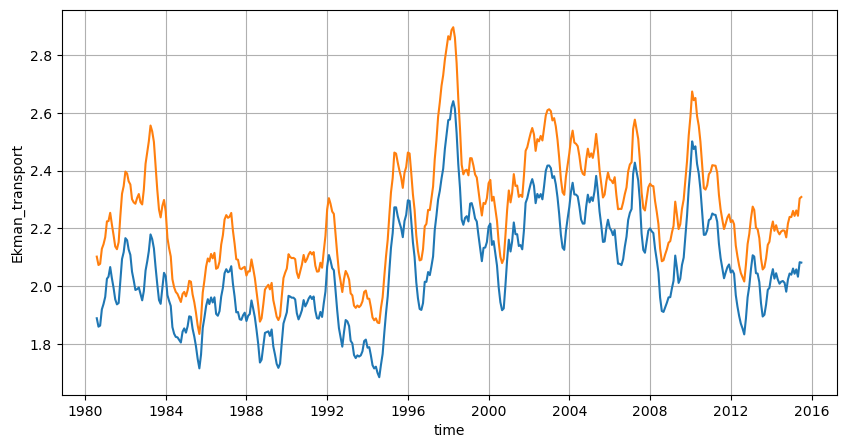

In [140]:
OGF = (CUTI_ds.CUTI - 2*EK_ds.Ekman_transport)*inshore_mask
OGF.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot(figsize=(10,5))
(EK_ds.Ekman_transport*inshore_mask*-1).sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot()

plt.grid()
OGF

(-85.0, -70.0)

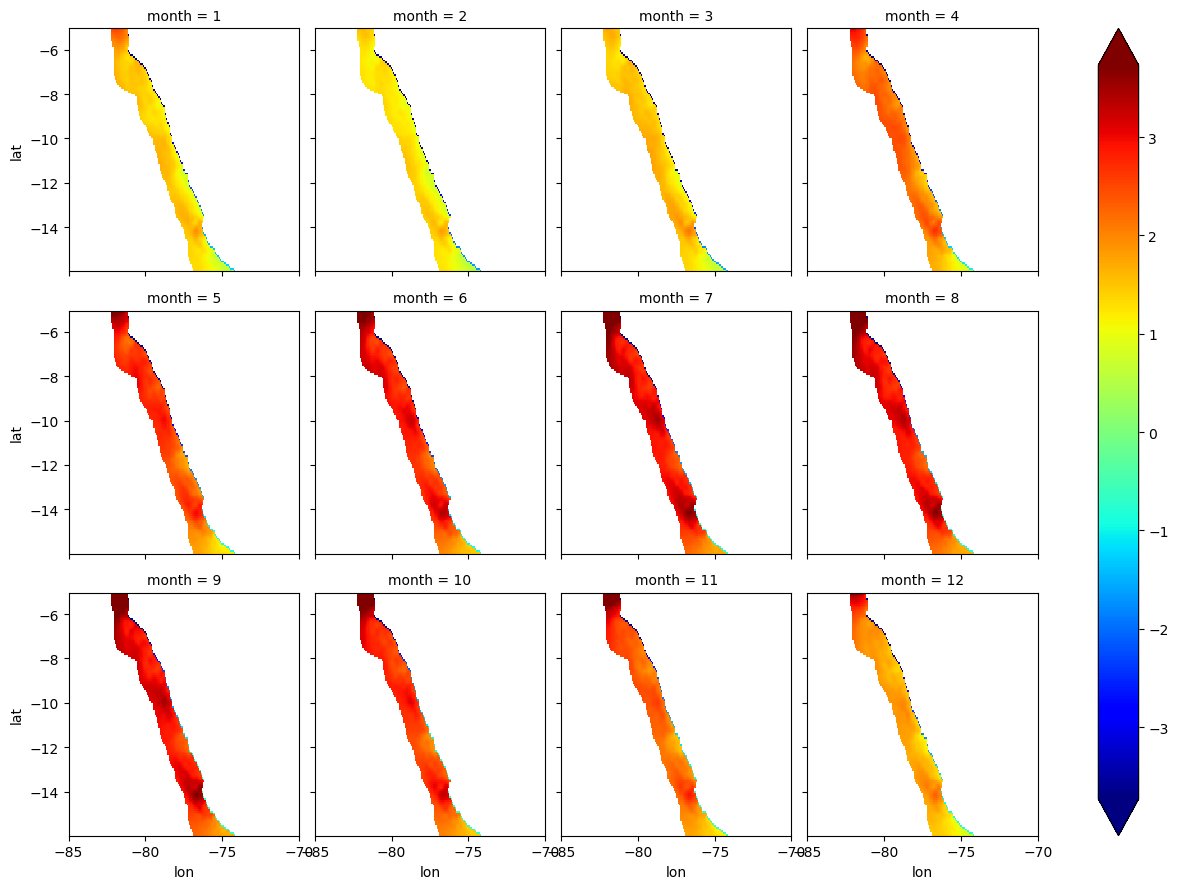

In [129]:
seasonality(OGF).sel(lat=slice(-16,-5)).plot(x="lon", y="lat",
                                              col = 'month', col_wrap=4, 
                                            robust=True,cmap='jet')
plt.xlim(-85,-70)

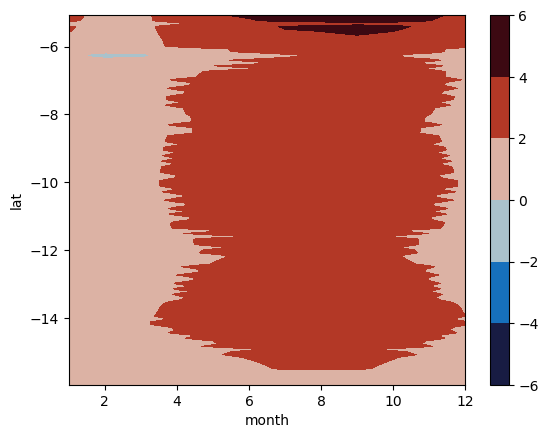

In [130]:
# season_OGF = seasonality(OGF) 
seasonality(OGF).sel(lat=slice(-16,-5)).mean(dim='lon',skipna=True).plot.contourf(x='month',
                                                                                 cmap=cm.balance)


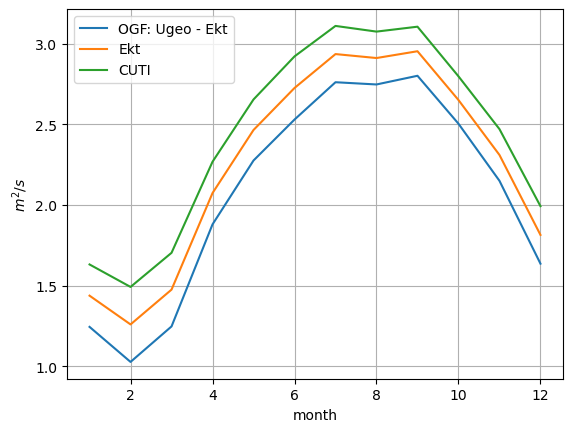

In [136]:
seasonality(OGF).sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True).plot(label='OGF: Ugeo - Ekt')
seasonality(EK_ds.Ekman_transport*inshore_mask*-1).sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True).plot(label='Ekt')
seasonality(CUTI_ds.CUTI*inshore_mask*-1).sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True).plot(label='CUTI')
plt.ylabel('$m^{2}/s$')
plt.grid()
plt.legend()